In [21]:
!pip install -q transformers datasets evaluate scikit-learn

import torch
import numpy as np
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding
)
from sklearn.metrics import f1_score, accuracy_score, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device, torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")

cuda Tesla T4


In [22]:
import os
import json
import tarfile
import urllib.request
from datasets import Dataset, DatasetDict, ClassLabel, Features, Value

# Download the official SciCite archive
url = "https://s3-us-west-2.amazonaws.com/ai2-s2-research/scicite/scicite.tar.gz"
archive_path = "/kaggle/working/scicite.tar.gz"
extract_dir = "/kaggle/working/scicite_raw"

if not os.path.exists(archive_path):
    urllib.request.urlretrieve(url, archive_path)

if not os.path.exists(extract_dir):
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(extract_dir)

# Find the jsonl files (they land in a nested "scicite" subfolder)
for root, dirs, files in os.walk(extract_dir):
    if "train.jsonl" in files:
        data_dir = root
        break

print("Data dir:", data_dir)
print(os.listdir(data_dir))

Data dir: /kaggle/working/scicite_raw/scicite
['train.jsonl', 'scaffolds', 'dev.jsonl', 'test.jsonl']


In [23]:
def load_jsonl(path):
    records = []
    with open(path) as f:
        for line in f:
            d = json.loads(line)
            records.append({"string": d["string"], "label": d["label"]})
    return records

train_records = load_jsonl(os.path.join(data_dir, "train.jsonl"))
val_records = load_jsonl(os.path.join(data_dir, "dev.jsonl"))
test_records = load_jsonl(os.path.join(data_dir, "test.jsonl"))

# Establish label set from the training data
label_names = sorted(set(r["label"] for r in train_records))
label2id = {l: i for i, l in enumerate(label_names)}
print(label_names)

class_label = ClassLabel(names=label_names)
features = Features({"string": Value("string"), "label": class_label})

def to_dataset(records):
    return Dataset.from_dict(
        {
            "string": [r["string"] for r in records],
            "label": [label2id[r["label"]] for r in records],
        },
        features=features,
    )

dataset = DatasetDict({
    "train": to_dataset(train_records),
    "validation": to_dataset(val_records),
    "test": to_dataset(test_records),
})

print(dataset)
print(dataset["train"][0])

num_labels = len(label_names)

['background', 'method', 'result']
DatasetDict({
    train: Dataset({
        features: ['string', 'label'],
        num_rows: 8243
    })
    validation: Dataset({
        features: ['string', 'label'],
        num_rows: 916
    })
    test: Dataset({
        features: ['string', 'label'],
        num_rows: 1861
    })
})
{'string': 'However, how frataxin interacts with the Fe-S cluster biosynthesis components remains unclear as direct one-to-one interactions with each component were reported (IscS [12,22], IscU/Isu1 [6,11,16] or ISD11/Isd11 [14,15]).', 'label': 0}


In [24]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_fn(batch):
    return tokenizer(
        batch["string"],
        truncation=True,
        max_length=256,
        padding=False,  # dynamic padding via collator
    )

tokenized = dataset.map(tokenize_fn, batched=True)
tokenized = tokenized.remove_columns(
    [c for c in dataset["train"].column_names if c not in ("label",)]
)
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/8243 [00:00<?, ? examples/s]

Map:   0%|          | 0/916 [00:00<?, ? examples/s]

Map:   0%|          | 0/1861 [00:00<?, ? examples/s]

In [25]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label={i: l for i, l in enumerate(label_names)},
    label2id={l: i for i, l in enumerate(label_names)},
).to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [26]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }

In [27]:
training_args = TrainingArguments(
    output_dir="/kaggle/working/bert-scicite",
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,           # checkpoint every 100 steps, not just per epoch
    save_total_limit=3,       # keep last 3 checkpoints, avoid filling disk
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_ratio=0.06,
    logging_steps=50,
    fp16=True,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [28]:
import transformers
print(transformers.__version__)

5.0.0


In [29]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
100,1.175657,0.958822,0.812227,0.787206,0.813230
200,0.841426,0.834620,0.848253,0.826903,0.847774
300,0.706379,0.903229,0.847162,0.817473,0.843227
400,0.600004,0.878299,0.850437,0.828430,0.850254
500,0.604601,0.818567,0.855895,0.835330,0.855287
600,0.450718,0.890047,0.852620,0.830167,0.852189
700,0.428127,0.901089,0.853712,0.832429,0.852775
800,0.408318,0.934609,0.850437,0.827175,0.849299
900,0.268289,1.024507,0.853712,0.832060,0.853029
1000,0.323442,1.039169,0.853712,0.830032,0.853189


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1032, training_loss=0.6153424996738286, metrics={'train_runtime': 582.1283, 'train_samples_per_second': 56.64, 'train_steps_per_second': 1.773, 'total_flos': 2344226981516406.0, 'train_loss': 0.6153424996738286, 'epoch': 4.0})

In [30]:
test_results = trainer.predict(tokenized["test"])
preds = np.argmax(test_results.predictions, axis=-1)
labels = test_results.label_ids

print(classification_report(labels, preds, target_names=label_names))

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


              precision    recall  f1-score   support

  background       0.89      0.88      0.88       997
      method       0.87      0.83      0.85       605
      result       0.76      0.87      0.81       259

    accuracy                           0.86      1861
   macro avg       0.84      0.86      0.85      1861
weighted avg       0.86      0.86      0.86      1861



In [31]:
trainer.save_model("/kaggle/working/bert-scicite-final")
tokenizer.save_pretrained("/kaggle/working/bert-scicite-final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/kaggle/working/bert-scicite-final/tokenizer_config.json',
 '/kaggle/working/bert-scicite-final/tokenizer.json')

In [32]:
# At the end of a session, or periodically via a cell you rerun manually:
import kagglehub
# or use the Kaggle API directly if kagglehub isn't set up:
!kaggle datasets version -p /kaggle/working/bert-scicite -m "checkpoint update" -r zip

Metadata file not found: dataset-metadata.json


In [33]:
from transformers import AutoModelForSequenceClassification

vanilla_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_labels,
    id2label={i: l for i, l in enumerate(label_names)},
    label2id={l: i for i, l in enumerate(label_names)},
).to(device)

vanilla_args = TrainingArguments(
    output_dir="/kaggle/working/bert-vanilla-eval",
    per_device_eval_batch_size=32,
    fp16=True,
    report_to="none",
)

vanilla_trainer = Trainer(
    model=vanilla_model,
    args=vanilla_args,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

vanilla_test_results = vanilla_trainer.predict(tokenized["test"])
vanilla_preds = np.argmax(vanilla_test_results.predictions, axis=-1)

print("=== Vanilla BERT (untrained head) ===")
print(classification_report(labels, vanilla_preds, target_names=label_names))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packag

=== Vanilla BERT (untrained head) ===
              precision    recall  f1-score   support

  background       0.00      0.00      0.00       997
      method       0.32      0.96      0.49       605
      result       0.14      0.04      0.07       259

    accuracy                           0.32      1861
   macro avg       0.16      0.33      0.18      1861
weighted avg       0.13      0.32      0.17      1861



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [34]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Vanilla BERT (random head)", "Finetuned BERT (SciCite)"],
    "Accuracy": [
        accuracy_score(labels, vanilla_preds),
        accuracy_score(labels, preds),
    ],
    "F1 (macro)": [
        f1_score(labels, vanilla_preds, average="macro"),
        f1_score(labels, preds, average="macro"),
    ],
    "F1 (weighted)": [
        f1_score(labels, vanilla_preds, average="weighted"),
        f1_score(labels, preds, average="weighted"),
    ],
})
print(comparison.to_string(index=False))

                     Model  Accuracy  F1 (macro)  F1 (weighted)
Vanilla BERT (random head)  0.317571    0.183676       0.166926
  Finetuned BERT (SciCite)  0.861902    0.848635       0.862437


In [35]:
from collections import Counter

majority_class = Counter(list(tokenized["train"]["labels"])).most_common(1)[0][0]
majority_preds = np.full_like(labels, majority_class)

print("=== Majority-class baseline ===")
print(classification_report(labels, majority_preds, target_names=label_names, zero_division=0))

comparison.loc[len(comparison)] = [
    "Majority-class baseline",
    accuracy_score(labels, majority_preds),
    f1_score(labels, majority_preds, average="macro", zero_division=0),
    f1_score(labels, majority_preds, average="weighted", zero_division=0),
]
print(comparison.to_string(index=False))

=== Majority-class baseline ===
              precision    recall  f1-score   support

  background       0.54      1.00      0.70       997
      method       0.00      0.00      0.00       605
      result       0.00      0.00      0.00       259

    accuracy                           0.54      1861
   macro avg       0.18      0.33      0.23      1861
weighted avg       0.29      0.54      0.37      1861

                     Model  Accuracy  F1 (macro)  F1 (weighted)
Vanilla BERT (random head)  0.317571    0.183676       0.166926
  Finetuned BERT (SciCite)  0.861902    0.848635       0.862437
   Majority-class baseline  0.535733    0.232564       0.373776


In [36]:
import os

# Point this at wherever your checkpoints landed after re-importing the dataset
checkpoint_dir = "/kaggle/input/bert-scicite-checkpoints/bert-scicite"

# Find the latest checkpoint subdirectory
checkpoints = [
    os.path.join(checkpoint_dir, d) for d in os.listdir(checkpoint_dir)
    if d.startswith("checkpoint-")
]
latest_checkpoint = max(checkpoints, key=lambda x: int(x.split("-")[-1])) if checkpoints else None
print("Resuming from:", latest_checkpoint)

# Rebuild trainer exactly as before (model, args, datasets, etc. — Cells 1-6 unchanged)
# Kaggle input mounts are read-only, so redirect output_dir back to /kaggle/working
training_args.output_dir = "/kaggle/working/bert-scicite"

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train(resume_from_checkpoint=latest_checkpoint)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/bert-scicite-checkpoints/bert-scicite'

# lora finetuning

In [37]:
!pip install -q peft

In [38]:
!pip uninstall -y torchao

In [39]:
from peft import LoraConfig, get_peft_model, TaskType

base_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_labels,
    id2label={i: l for i, l in enumerate(label_names)},
    label2id={l: i for i, l in enumerate(label_names)},
).to(device)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,                          # rank — start here, compare r=16 later if curious
    lora_alpha=16,                # scaling factor, commonly 2x rank
    lora_dropout=0.1,
    target_modules=["query", "value"],  # standard choice for BERT attention layers
    bias="none",
)

lora_model = get_peft_model(base_model, lora_config)
lora_model.print_trainable_parameters()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 297,219 || all params: 109,781,766 || trainable%: 0.2707


In [40]:
lora_training_args = TrainingArguments(
    output_dir="/kaggle/working/bert-lora-scicite",
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=3,
    learning_rate=2e-4,           # LoRA typically wants a higher LR than full FT — 2e-5 is often too low
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_ratio=0.06,
    logging_steps=50,
    fp16=True,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="none",
)

lora_trainer = Trainer(
    model=lora_model,
    args=lora_training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [41]:
from transformers import EarlyStoppingCallback

lora_trainer.add_callback(EarlyStoppingCallback(early_stopping_patience=3))

In [42]:
lora_trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
100,1.829688,1.635160,0.640830,0.366595,0.542628
200,1.176281,0.953627,0.827511,0.793282,0.825346
300,0.890514,0.897260,0.841703,0.808012,0.837450
400,0.832225,0.941144,0.811135,0.780682,0.814121
500,0.812663,0.826464,0.847162,0.825587,0.846858
600,0.784528,0.832643,0.842795,0.821067,0.842978
700,0.714921,0.825690,0.846070,0.822119,0.845320
800,0.764717,0.806682,0.859170,0.836345,0.857911
900,0.675548,0.823926,0.856987,0.835485,0.855973
1000,0.689789,0.816847,0.853712,0.832140,0.853049


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

TrainOutput(global_step=1032, training_loss=0.9376875041991242, metrics={'train_runtime': 465.8398, 'train_samples_per_second': 70.78, 'train_steps_per_second': 2.215, 'total_flos': 2352361923206892.0, 'train_loss': 0.9376875041991242, 'epoch': 4.0})

In [43]:
print("Best checkpoint:", lora_trainer.state.best_model_checkpoint)

lora_test_results = lora_trainer.predict(tokenized["test"])
lora_preds = np.argmax(lora_test_results.predictions, axis=-1)
labels = lora_test_results.label_ids

print("=== LoRA finetuned BERT (SciCite) ===")
print(classification_report(labels, lora_preds, target_names=label_names))

Best checkpoint: /kaggle/working/bert-lora-scicite/checkpoint-800


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


=== LoRA finetuned BERT (SciCite) ===
              precision    recall  f1-score   support

  background       0.87      0.89      0.88       997
      method       0.91      0.80      0.85       605
      result       0.75      0.90      0.82       259

    accuracy                           0.86      1861
   macro avg       0.84      0.86      0.85      1861
weighted avg       0.87      0.86      0.86      1861



In [44]:
comparison.loc[len(comparison)] = [
    "LoRA finetuned BERT (SciCite)",
    accuracy_score(labels, lora_preds),
    f1_score(labels, lora_preds, average="macro"),
    f1_score(labels, lora_preds, average="weighted"),
]
print(comparison.to_string(index=False))

                        Model  Accuracy  F1 (macro)  F1 (weighted)
   Vanilla BERT (random head)  0.317571    0.183676       0.166926
     Finetuned BERT (SciCite)  0.861902    0.848635       0.862437
      Majority-class baseline  0.535733    0.232564       0.373776
LoRA finetuned BERT (SciCite)  0.861902    0.849288       0.862121


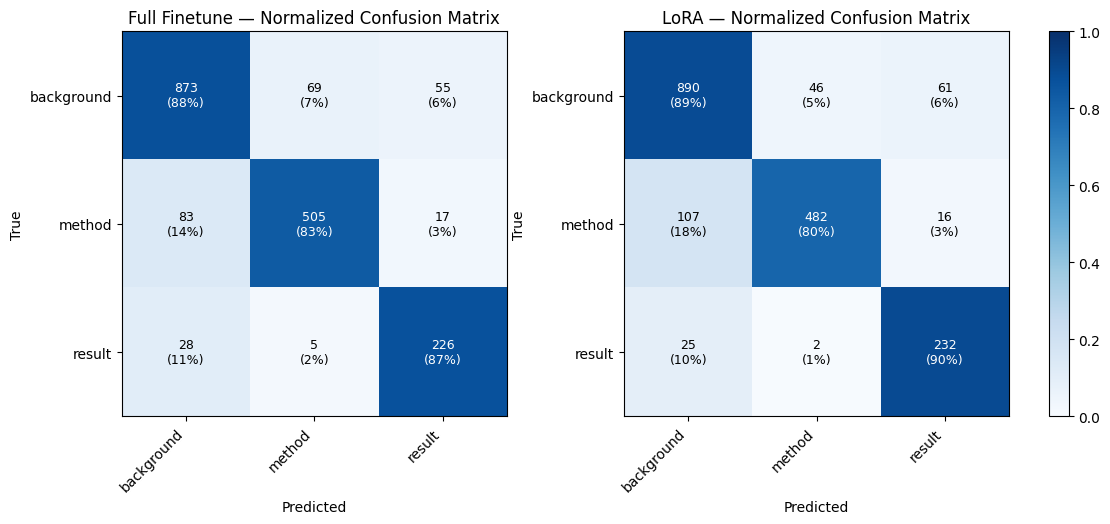

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model_preds, title in [
    (axes[0], preds, "Full Finetune"),
    (axes[1], lora_preds, "LoRA"),
]:
    cm = confusion_matrix(labels, model_preds)
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(num_labels))
    ax.set_yticks(range(num_labels))
    ax.set_xticklabels(label_names, rotation=45, ha="right")
    ax.set_yticklabels(label_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{title} — Normalized Confusion Matrix")

    for i in range(num_labels):
        for j in range(num_labels):
            count = cm[i, j]
            pct = cm_norm[i, j]
            color = "white" if pct > 0.5 else "black"
            ax.text(j, i, f"{count}\n({pct:.0%})", ha="center", va="center", color=color, fontsize=9)

fig.colorbar(im, ax=axes, fraction=0.046, pad=0.04)
plt.savefig("/kaggle/working/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [46]:
print("=== Full Finetune Confusion Matrix ===")
cm_full = confusion_matrix(labels, preds)
print(pd.DataFrame(cm_full, index=label_names, columns=label_names))

print("\n=== LoRA Confusion Matrix ===")
cm_lora = confusion_matrix(labels, lora_preds)
print(pd.DataFrame(cm_lora, index=label_names, columns=label_names))

print("\n=== Difference (LoRA - Full FT), positive = LoRA predicts this more ===")
print(pd.DataFrame(cm_lora - cm_full, index=label_names, columns=label_names))

=== Full Finetune Confusion Matrix ===
            background  method  result
background         873      69      55
method              83     505      17
result              28       5     226

=== LoRA Confusion Matrix ===
            background  method  result
background         890      46      61
method             107     482      16
result              25       2     232

=== Difference (LoRA - Full FT), positive = LoRA predicts this more ===
            background  method  result
background          17     -23       6
method              24     -23      -1
result              -3      -3       6


In [47]:
comparison = pd.DataFrame({
    "Model": [
        "Vanilla BERT (random head)",
        "Majority-class baseline",
        "Full Finetune",
        "LoRA (r=8)",
    ],
    "Accuracy": [
        accuracy_score(labels, vanilla_preds),
        accuracy_score(labels, majority_preds),
        accuracy_score(labels, preds),
        accuracy_score(labels, lora_preds),
    ],
    "F1 (macro)": [
        f1_score(labels, vanilla_preds, average="macro", zero_division=0),
        f1_score(labels, majority_preds, average="macro", zero_division=0),
        f1_score(labels, preds, average="macro"),
        f1_score(labels, lora_preds, average="macro"),
    ],
    "F1 (weighted)": [
        f1_score(labels, vanilla_preds, average="weighted", zero_division=0),
        f1_score(labels, majority_preds, average="weighted", zero_division=0),
        f1_score(labels, preds, average="weighted"),
        f1_score(labels, lora_preds, average="weighted"),
    ],
    "Trainable Params": [
        "0 (frozen, random head)",
        "N/A",
        "109.8M (100%)",
        "296K (0.27%)",
    ],
})

print(comparison.to_string(index=False))
comparison.to_csv("/kaggle/working/model_comparison.csv", index=False)

                     Model  Accuracy  F1 (macro)  F1 (weighted)        Trainable Params
Vanilla BERT (random head)  0.317571    0.183676       0.166926 0 (frozen, random head)
   Majority-class baseline  0.535733    0.232564       0.373776                     N/A
             Full Finetune  0.861902    0.848635       0.862437           109.8M (100%)
                LoRA (r=8)  0.861902    0.849288       0.862121            296K (0.27%)
